In [14]:
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

# 1. Carregar o conjunto de dados ERA5
# Usarei xr.open_dataset para ler o arquivo NetCDF
data_path = '/content/era5_dataset.nc'
ds = xr.open_dataset(data_path)

# 2. Selecionei as variáveis meteorológicas principais para o resumo
colunas_interesse = ['d2m', 't2m', 'sp', 'u100', 'v100', 'z']
# Filtrei apenas as colunas que existem no Dataset para evitar novos erros
colunas_presentes = [c for c in colunas_interesse if c in ds.data_vars]
tabela_estatistica = ds[colunas_presentes].to_dataframe().describe() # Convert to DataFrame for .describe()

print("Estatística Descritiva do ERA5:")
display(tabela_estatistica)

# 3. Verifiquei se existem dados nulos
print("\nVerificação de lacunas (dados faltantes):")
print(ds[colunas_presentes].isnull().sum())

Estatística Descritiva do ERA5:


,d2m,t2m,sp,u100,v100,z,number
count,76440.000000,76440.000000,76440.000000,76440.000000,76440.000000,76440.000000,76440.0
mean,296.078247,301.155426,100755.234375,-6.222261,-2.893291,297.556793,0.0
std,1.463238,2.581281,416.105316,2.593695,2.243009,310.264496,0.0
min,285.433350,295.547241,99500.406250,-14.395645,-9.783936,-5.157715,0.0
25%,295.675964,299.752304,100422.937500,-8.154102,-4.573269,1.850098,0.0
50%,296.507141,300.437363,100846.875000,-6.066154,-3.066147,186.213379,0.0
75%,296.994995,301.536728,101089.750000,-4.247189,-1.388039,619.646973,0.0
max,298.763672,311.202148,101661.000000,3.073700,5.724304,933.174316,0.0



Verificação de lacunas (dados faltantes):
<xarray.Dataset> Size: 56B
Dimensions:  ()
Coordinates:
    number   int64 8B 0
Data variables:
    d2m      int64 8B 0
    t2m      int64 8B 0
    sp       int64 8B 0
    u100     int64 8B 0
    v100     int64 8B 0
    z        int64 8B 0
Attributes:
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             European Centre for Medium-Range Weather Forecasts
    history:                 2026-06-10T14:13 GRIB to CDM+CF via cfgrib-0.9.1...


In [15]:
# Verificar o alcance temporal dos metadados
print(f"Início da série ERA5: {ds.valid_time.min().values}")
print(f"Fim da série ERA5:    {ds.valid_time.max().values}")

# Verificar a resolução temporal (deve ser 1 hora)
diff = ds.valid_time.diff('valid_time').values
print(f"Frequência dos dados: {np.unique(diff)}")

Início da série ERA5: 2021-09-01T00:00:00.000000000
Fim da série ERA5:    2021-11-30T23:00:00.000000000
Frequência dos dados: [3600000000000]


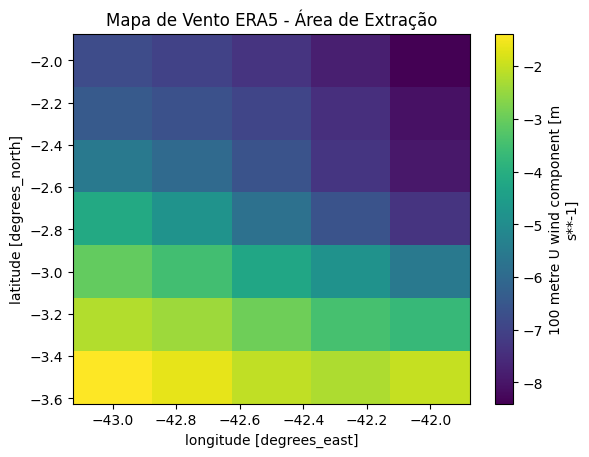

In [16]:
# 2. Visualizar a estrutura do "cubo de dados", duas estruturas de visualização:
#a estrutura geral do dataset e um mapa específico da variável de vento u100 para o primeiro tempo válido.

ds.u100.isel(valid_time=0).plot()
plt.title("Mapa de Vento ERA5 - Área de Extração")
plt.show()

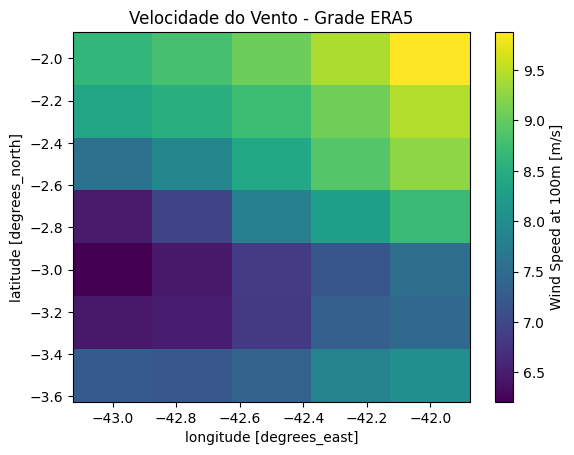

In [17]:
# Criar ws100 diretamente no Dataset (cubo)
ds['ws100'] = (ds.u100**2 + ds.v100**2)**0.5
ds.ws100.attrs['units'] = 'm/s'
ds.ws100.attrs['long_name'] = 'Wind Speed at 100m'

# Plotar o primeiro passo de tempo de toda a grade
ds.ws100.isel(valid_time=0).plot()
plt.title("Velocidade do Vento - Grade ERA5")
plt.show()

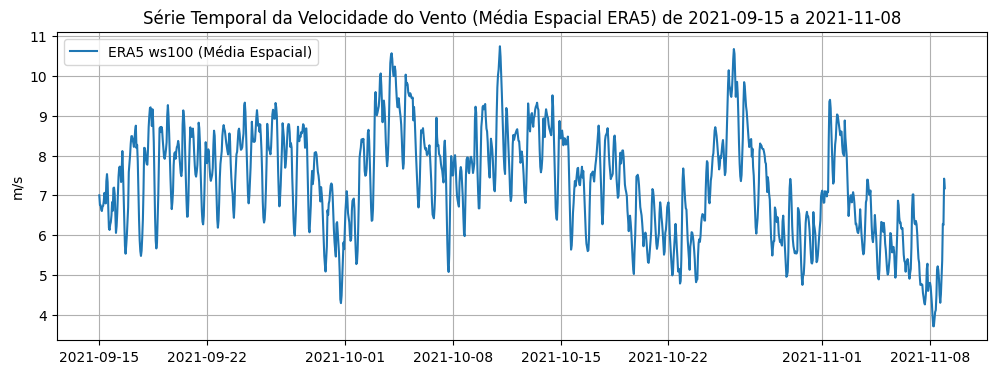

In [20]:
# Visualização 1: Série Temporal Completa
plt.figure(figsize=(12, 4))

# Definir o período de interesse, no caso o partiodo de 15 de setembro até 08 de novembro
start_time = '2021-09-15T00:00:00'
end_time = '2021-11-08T23:00:00'

# Selecionar o subconjunto de dados para o período especificado
ds_subset = ds.sel(valid_time=slice(start_time, end_time))

# Calcular a média de ws100 sobre as dimensões espaciais (latitude e longitude)
# para obter uma série temporal 1D para o subconjunto.
ws100_mean_spatial = ds_subset['ws100'].mean(dim=['latitude', 'longitude'])

plt.plot(ds_subset['valid_time'], ws100_mean_spatial, label='ERA5 ws100 (Média Espacial)')
plt.title(f"Série Temporal da Velocidade do Vento (Média Espacial ERA5) de {start_time[:10]} a {end_time[:10]}")
plt.ylabel("m/s")
plt.legend()
plt.grid(True)
plt.show()